# ICT-42b — Inoculation et bifurcation : la troisième échelle (9B)
**Navigation** : [Index](README.md) | [44 — Geometry of Truth](ICT-44-GeometryOfTruth-Python.ipynb) | [46 — Strate 7 : freebits de second ordre](ICT-46-Strate7-FreeCoordinates-Python.ipynb)

Ce carnet étend le pilote **ICT-42** à la troisième taille, **Qwen3.5-9B-Base** (32 couches, SAE Qwen-Scope W64K-L0_50, 65 536 features) — le couple de référence historique de la série (#5101), apparié en génération au 2B du pilote (tous deux Qwen3.5, saut ×4.5). La question du pilote se repose à cette échelle : **l'inoculation d'un panel de features SAE à mi-profondeur provoque-t-elle une bifurcation représentationnelle, et cette bifurcation durcit-elle ou s'adoucit-elle quand la taille croît ?**


> **Statut épistémique** — Extension d'échelle du pilote ICT-42 (sans verdict à ce jour sur la matrice de dissociation). Les deux échelles du pilote montraient des régimes opposés (réponse massive précoce du 1.7B, transition plus tardive et douce du 2B) ; ce carnet mesure où le 9B se situe, et ne prétend à aucun verdict tant que la lecture croisée des trois échelles n'est pas faite. Les mêmes garde-fous que le pilote s'appliquent.


## Garde-fous d'honnêteté (à lire avant les résultats)

- **Le banc est numpy-only et GPU-free.** Toutes les traces proviennent du pipeline `scripts/extract_sae_traces.py` (mode inoculation : `--clamp-frac 0.5` / lecture resid final), exécuté une fois par intensité α ; ce carnet ne fait que lire les `.npz` et calculer les statistiques.
- **Le contrôle de plomberie α = 0 est dans le sweep.** La trace à intensité nulle passe par le hook d'inoculation actif mais neutre (`h' = h − 0·δ`) : toute divergence non nulle mesurée à α = 0 serait un artefact d'implémentation. Elle est vérifiée nulle avant toute lecture.
- **La divergence est mesurée dans l'espace SAE top-k** (activations reconstituées des vecteurs creux stockés), pas sur le residual stream complet.
- **Les trois échelles ont des dictionnaires indépendants.** W32K (32 768 features) pour 1.7B et 2B, **W64K (65 536 features) pour le 9B** : les ids ne sont pas appariés, la comparaison cross-échelle porte sur la **forme** des courbes m(α), jamais sur des ids partagés.
- **Nom des traces 9B sans slug.** Le 9B étant le modèle de référence historique de `trace_filename`, ses traces s'écrivent `inoc_layer31_…` (pas `inoc_qwen35-9b-base_layer31of32_…`) — convention byte-identique aux traces `ict21_sae_layer16_*` existantes.
- **Chaque intensité α est une passe indépendante** (clamp appliqué une fois, propagation vers l'avant) : le protocole ne mesure pas d'hystérésis.


## Protocole : inoculer à mi-profondeur, lire au residual final

Identique au pilote ICT-42, transposé par profondeur relative :

| Échelle | Couches | Inoculation (frac 0.5) | Lecture (resid final) | SAE | d_sae |
|---|---|---|---|---|---|
| Qwen3-1.7B-Base | 28 | 14 | 27 | W32K-L0_50 | 32 768 |
| Qwen3.5-2B-Base | 24 | 12 | 23 | W32K-L0_50 | 32 768 |
| Qwen3.5-9B-Base | 32 | **16** | **31** | **W64K-L0_50** | **65 536** |

Le panel inoculé = **top-16 différentiel** `|mean_act(code_python) − mean_act(prose_fr)|` dérivé de la trace de référence mi-réseau de chaque échelle. Intensités α ∈ {0, 0.25, 0.5, 0.75, 1.0} ; contrôles permuté (`inocrp`, tirage uniforme seed 42) et apparié en norme (`inocmp`, bande d'activité ×2) aux α mesurés du pilote {0.25, 1.0}.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRACES = Path("traces")
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]

# Le 9B est le modele de REFERENCE de trace_filename : ses traces n'ont NI
# slug NI suffixe of{n} (convention historique ict21_sae_layer16_*). Les deux
# autres echelles suivent la convention slug du pilote.
ECHELLES = {
    "Qwen3-1.7B-Base": dict(slug="qwen3-17b-base", n_layers=28,
                            ref="ict21_sae_qwen3-17b-base_layer14of28_trained.npz"),
    "Qwen3.5-2B-Base": dict(slug="qwen35-2b-base", n_layers=24,
                            ref="ict21_sae_qwen35-2b-base_layer12of24_trained.npz"),
    "Qwen3.5-9B-Base": dict(slug=None, n_layers=32,
                            ref="ict21_sae_layer16_trained.npz"),
}


def _base(echelle, prefix="inoc"):
    cfg = ECHELLES[echelle]
    if cfg["slug"]:
        depth = f"layer{cfg['n_layers'] - 1}of{cfg['n_layers']}"
        return f"{prefix}_{cfg['slug']}_{depth}_trained_clamp16"
    return f"{prefix}_layer{cfg['n_layers'] - 1}_trained_clamp16"


def inoc_path(echelle, alpha):
    suffix = "" if abs(alpha - 1.0) < 1e-9 else f"_s{alpha:g}"
    return TRACES / f"{_base(echelle)}{suffix}.npz"


def ctrl_path(prefix, echelle, alpha):
    suffix = "" if abs(alpha - 1.0) < 1e-9 else f"_s{alpha:g}"
    return TRACES / f"{_base(echelle, prefix)}{suffix}.npz"


def inocref_path(echelle):
    cfg = ECHELLES[echelle]
    if cfg["slug"]:
        depth = f"layer{cfg['n_layers'] - 1}of{cfg['n_layers']}"
        return TRACES / f"inocref_{cfg['slug']}_{depth}_trained.npz"
    return TRACES / f"inocref_layer{cfg['n_layers'] - 1}_trained.npz"


def load_meta(path):
    z = np.load(path, allow_pickle=False)
    return json.loads(str(z["__meta__"]))


def prompt_keys(z):
    return sorted({k.rsplit("__", 1)[0] for k in z.files
                   if k.endswith("__topk_ids")})


def sparse_vec(z, key, d_sae):
    ids = z[f"{key}__topk_ids"].astype(np.int64).ravel()
    vals = z[f"{key}__topk_vals"].astype(np.float64).ravel()
    v = np.zeros(d_sae, dtype=np.float64)
    np.add.at(v, ids, vals)
    return v


rows = []
for label, cfg in ECHELLES.items():
    for a in ALPHAS:
        p = inoc_path(label, a)
        assert p.exists(), f"trace absente : {p} (regenerer via extract_sae_traces.py --prefix inoc)"
        meta = load_meta(p)
        rows.append({
            "echelle": label, "alpha": meta["clamp_scale"],
            "clamp_layer": meta["clamp_layer"], "read_layer": meta["read_layer"],
            "n_clamp": len(meta["clamp_ids"]), "k": meta["k"],
            "d_sae": meta["d_sae"], "tokens": meta["n_tokens_total"],
        })
inventaire = pd.DataFrame(rows).sort_values(["echelle", "alpha"]).reset_index(drop=True)
inventaire


,echelle,alpha,clamp_layer,read_layer,n_clamp,k,d_sae,tokens
0,Qwen3-1.7B-Base,0.00,14,27,16,50,32768,2759
1,Qwen3-1.7B-Base,0.25,14,27,16,50,32768,2759
2,Qwen3-1.7B-Base,0.50,14,27,16,50,32768,2759
3,Qwen3-1.7B-Base,0.75,14,27,16,50,32768,2759
4,Qwen3-1.7B-Base,1.00,14,27,16,50,32768,2759
5,Qwen3.5-2B-Base,0.00,12,23,16,50,32768,2699
6,Qwen3.5-2B-Base,0.25,12,23,16,50,32768,2699
7,Qwen3.5-2B-Base,0.50,12,23,16,50,32768,2699
8,Qwen3.5-2B-Base,0.75,12,23,16,50,32768,2699
9,Qwen3.5-2B-Base,1.00,12,23,16,50,32768,2699


**Lecture de l'inventaire.** La géométrie est cohérente sur les trois échelles : inoculation à la couche mi-réseau (16/31 pour le 9B, frac 0.516 — même position relative que 14/28 et 12/24), lecture au residual final, 16 features clampées, top-k officiel k=50 partout. Le corpus est strictement identique (2 699 tokens, mêmes 5 jeux × 4 prompts) : les trois bancs comparent la même intervention sur la même entrée. Seul le dictionnaire change (65 536 features pour le 9B contre 32 768 aux deux autres échelles).


In [2]:
# Controle de plomberie : a alpha = 0, le hook d'inoculation est actif mais
# neutre (h' = h - 0*delta). Les ids top-k doivent etre IDENTIQUES a la
# reference sans hook (inocref), token pour token.

rows = []
for label, cfg in ECHELLES.items():
    z0 = np.load(inoc_path(label, 0.0), allow_pickle=False)
    zr = np.load(inocref_path(label), allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    same_ids, divs = True, []
    for key in prompt_keys(z0):
        ids0 = z0[f"{key}__topk_ids"].astype(np.int64).ravel()
        idsr = zr[f"{key}__topk_ids"].astype(np.int64).ravel()
        same_ids &= np.array_equal(ids0, idsr)
        x0 = sparse_vec(z0, key, d_sae)
        xr = sparse_vec(zr, key, d_sae)
        divs.append(float(np.abs(x0 - xr).sum() / np.abs(xr).sum()))
    rows.append({"echelle": label, "ids_topk_identiques": bool(same_ids),
                 "divergence_a0_max": float(np.max(divs))})
plomberie = pd.DataFrame(rows)
plomberie


,echelle,ids_topk_identiques,divergence_a0_max
0,Qwen3-1.7B-Base,True,0.0
1,Qwen3.5-2B-Base,True,0.0
2,Qwen3.5-9B-Base,True,0.0


**Contrôle de plomberie.** Sur les trois échelles, `ids_topk_identiques` = True et la divergence à α = 0 est exactement nulle (max 0.0e+00) : le hook d'inoculation actif mais neutre ne modifie rien — toute la divergence mesurée aux α > 0 est imputable au clamp, pas à la plomberie.


In [3]:
# Re-derivation du panel differentiel depuis la reference de chaque echelle
# (meme statistique que le pipeline : |mean_code - mean_prose|, top-16), et
# confrontation aux ids reellement inocules dans les traces du sweep.


def mean_by_set(z, set_name, d_sae):
    keys = sorted(k for k in z.files
                  if k.startswith(set_name + "__") and k.endswith("__topk_ids"))
    n_tok, hits = 0, np.zeros(d_sae, dtype=np.float64)
    for k in keys:
        ids = z[k].astype(np.int64).ravel()
        vals = z[k.rsplit("ids", 1)[0] + "vals"].astype(np.float64).ravel()
        np.add.at(hits, ids, vals)
        n_tok += ids.shape[0]
    return hits / max(n_tok, 1)


rows = []
for label, cfg in ECHELLES.items():
    zref = np.load(TRACES / cfg["ref"], allow_pickle=False)
    meta_ref = json.loads(str(zref["__meta__"]))
    d_sae = meta_ref["d_sae"]
    score = np.abs(mean_by_set(zref, "code_python", d_sae)
                   - mean_by_set(zref, "prose_fr", d_sae))
    top16 = sorted(int(i) for i in np.argsort(score)[::-1][:16])
    inocules = sorted(load_meta(inoc_path(label, 0.0))["clamp_ids"])
    rows.append({"echelle": label, "panel_rederive": str(top16),
                 "panel_inocule": str(inocules),
                 "identique": top16 == inocules})
pd.DataFrame(rows)


,echelle,panel_rederive,panel_inocule,identique
0,Qwen3-1.7B-Base,"[2076, 7036, 7258, 7662, 8520, 12503, 13170, 1...","[2076, 7036, 7258, 7662, 8520, 12503, 13170, 1...",True
1,Qwen3.5-2B-Base,"[701, 1673, 2919, 4314, 5272, 5680, 10586, 129...","[701, 1673, 2919, 4314, 5272, 5680, 10586, 129...",True
2,Qwen3.5-9B-Base,"[5595, 10365, 12255, 16060, 19350, 22736, 2451...","[5595, 10365, 12255, 16060, 19350, 22736, 2451...",True


**Panels.** La re-dérivation reproduit exactement les ids inoculés (`identique` = True sur les trois échelles) : le pipeline a bien clampé le top-16 différentiel `|mean_act(code) − mean_act(prose)|` issu de chaque référence mi-réseau. Les panels restent non appariés entre échelles (dictionnaires indépendants) — c'est la forme des courbes qu'on compare, pas les ids.


In [4]:
# Ordre-parametre : m(alpha) = ||x_a - x_0||_1 / ||x_0||_1 par prompt,
# moyennee par jeu puis par echelle (meme statistique que le pilote).


def divergence_table(echelle):
    p0 = inoc_path(echelle, 0.0)
    z0 = np.load(p0, allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    base = {k: sparse_vec(z0, k, d_sae) for k in prompt_keys(z0)}
    rows = []
    for a in ALPHAS:
        z = np.load(inoc_path(echelle, a), allow_pickle=False)
        for key in prompt_keys(z):
            x = sparse_vec(z, key, d_sae)
            rows.append({"alpha": a, "prompt": key,
                         "jeu": key.rsplit("__", 1)[0],
                         "m": float(np.abs(x - base[key]).sum()
                                    / np.abs(base[key]).sum())})
    return pd.DataFrame(rows)


tables = {label: divergence_table(label) for label in ECHELLES}
m_par_echelle = pd.DataFrame({
    label: t.groupby("alpha")["m"].mean() for label, t in tables.items()
}).round(4)
m_par_echelle


,Qwen3-1.7B-Base,Qwen3.5-2B-Base,Qwen3.5-9B-Base
alpha,,,
0.00,0.0000,0.0000,0.0000
0.25,0.3311,0.0450,0.0339
0.50,0.6800,0.1115,0.0717
0.75,0.9198,0.4065,0.1367
1.00,1.1034,0.6467,0.3267


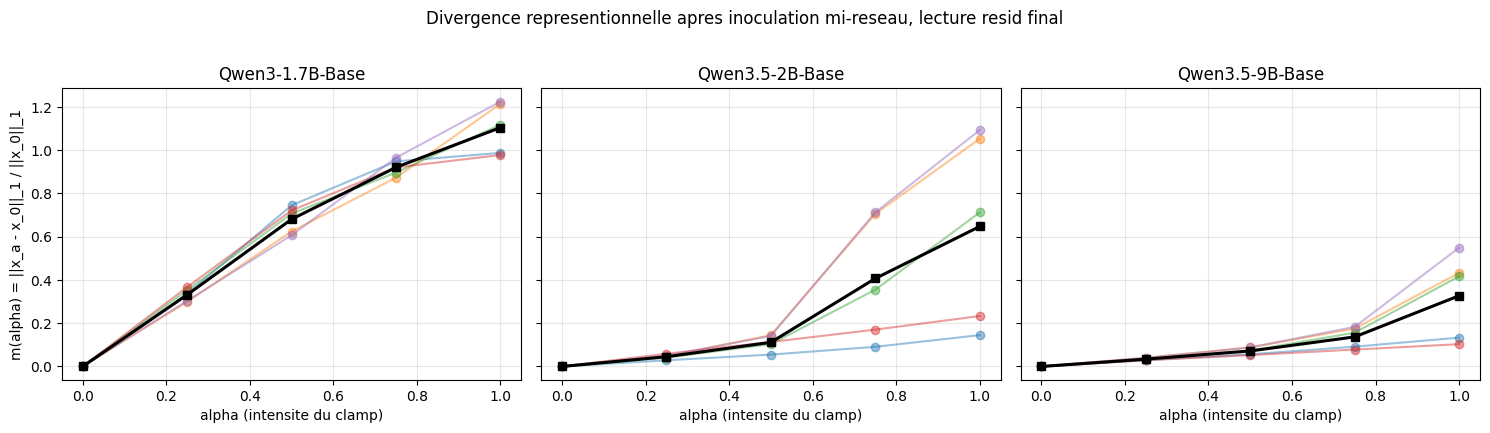

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (label, t) in zip(axes, tables.items()):
    for jeu, g in t.groupby("jeu"):
        agg = g.groupby("alpha")["m"].mean()
        ax.plot(agg.index, agg.values, marker="o", alpha=0.45, label=None)
    agg = t.groupby("alpha")["m"].mean()
    ax.plot(agg.index, agg.values, marker="s", color="black", lw=2.2, label="moyenne")
    ax.set_title(label)
    ax.set_xlabel("alpha (intensite du clamp)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("m(alpha) = ||x_a - x_0||_1 / ||x_0||_1")
fig.suptitle("Divergence representionnelle apres inoculation mi-reseau, lecture resid final", y=1.02)
fig.tight_layout()
plt.show()


**Lecture des courbes m(α).** Le 9B prolonge et amplifie la tendance entrevue du 1.7B vers le 2B. À α = 0.25, le 1.7B a déjà divergé de 33 % (m = 0.331), le 2B de 4.5 %, le 9B de 3.4 %. À α = 1, la divergence totale décroît avec la taille : m(1) = 1.103 → 0.647 → 0.327. Les trois régimes s'ordonnent : réponse massive et précoce du 1.7B, transition tardive du 2B, transition plus tardive encore et plus faible du 9B. À intervention identique (même position relative, même nombre de features, même intensité), la représentation finale du 9B bouge **deux fois moins** que celle du 2B et **trois fois moins** que celle du 1.7B.


In [6]:
# Nettete de la transition : pente locale dm/dalpha, point de pente maximale,
# et rapport m(0.25)/m(1) (fraction de la divergence deja presentee au
# premier quart d'intensite -- le tell du regime "precoce" du 1.7B).

rows = []
for label, t in tables.items():
    agg = t.groupby("alpha")["m"].mean().sort_index()
    a = agg.index.to_numpy(dtype=float)
    m = agg.values
    dm = np.diff(m) / np.diff(a)
    i_star = int(np.argmax(dm))
    rows.append({
        "echelle": label,
        "alpha_pente_max": float(a[i_star] + (a[1] - a[0]) / 2),
        "pente_max": float(dm[i_star]),
        "m_0.25_sur_m_1": float(agg.loc[0.25] / agg.loc[1.0]),
        "m(1)": float(agg.loc[1.0]),
    })
seuils = pd.DataFrame(rows)
seuils


,echelle,alpha_pente_max,pente_max,m_0.25_sur_m_1,m(1)
0,Qwen3-1.7B-Base,0.375,1.395571,0.300057,1.103380
1,Qwen3.5-2B-Base,0.625,1.179967,0.069602,0.646715
2,Qwen3.5-9B-Base,0.875,0.760167,0.103748,0.326702


**Seuil et netteté.** Le point de pente maximale recule **monotonement** avec la taille : α* ≈ 0.375 (1.7B) → 0.625 (2B) → 0.875 (9B) — la transition se décale vers les hautes intensités. Et la pente maximale elle-même s'adoucit : 1.40 → 1.18 → 0.76. La fraction de divergence déjà acquise au premier quart d'intensité (m(0.25)/m(1)) reste faible hors 1.7B : 0.30 → 0.07 → 0.10. Les deux signatures convergent : plus le modèle est grand, plus la bifurcation exige d'intensité et plus elle est douce quand elle arrive.


In [7]:
# Profil token-par-token : divergence creuse LOCALE par position, moyennee
# par echelle (ou la perturbation se dissout-elle le long du contexte ?).

rows = []
for label in ECHELLES:
    z0 = np.load(inoc_path(label, 0.0), allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    prof = {}
    for a in (0.25, 0.5, 1.0):
        z = np.load(inoc_path(label, a), allow_pickle=False)
        rel = []
        for key in prompt_keys(z):
            ids0 = z0[f"{key}__topk_ids"].astype(np.int64)
            idsa = z[f"{key}__topk_ids"].astype(np.int64)
            T = min(ids0.shape[1], idsa.shape[1])
            for t in range(T):
                s0 = set(ids0[:, t].tolist()) if ids0.ndim > 1 else set(ids0[t].tolist())
                sa = set(idsa[:, t].tolist()) if idsa.ndim > 1 else set(idsa[t].tolist())
                rel.append(1.0 - len(s0 & sa) / max(len(s0 | sa), 1))
        prof[a] = float(np.mean(rel))
    rows.append({"echelle": label, **{f"jaccard_inv_a{a:g}": v for a, v in prof.items()}})
profils = pd.DataFrame(rows)
profils


,echelle,jaccard_inv_a0.25,jaccard_inv_a0.5,jaccard_inv_a1
0,Qwen3-1.7B-Base,0.817237,0.860391,0.905846
1,Qwen3.5-2B-Base,0.635281,0.734678,0.851725
2,Qwen3.5-9B-Base,0.587481,0.695555,0.811007


**Profil ensembliste.** L'indice de Jaccard inverse (fraction du top-50 **remplacé**, indépendamment des valeurs) raconte une histoire complémentaire de m(α) : à α = 1, le remplacement de l'ensemble reste substantiel aux trois échelles (0.906 → 0.852 → 0.811) — même le 9B, dont la divergence de *valeurs* m(1) = 0.33 est la plus faible, **remplace plus de 80 % de son top-50**. La hiérarchie des échelles s'inverse selon la statistique : le 9B diverge le moins en magnitude mais reste proche du 2B en rotation d'ensemble. La bifurcation du 9B est donc moins une "cassure des valeurs" qu'une réorganisation des features actives — à confronter à l'exercice 1.


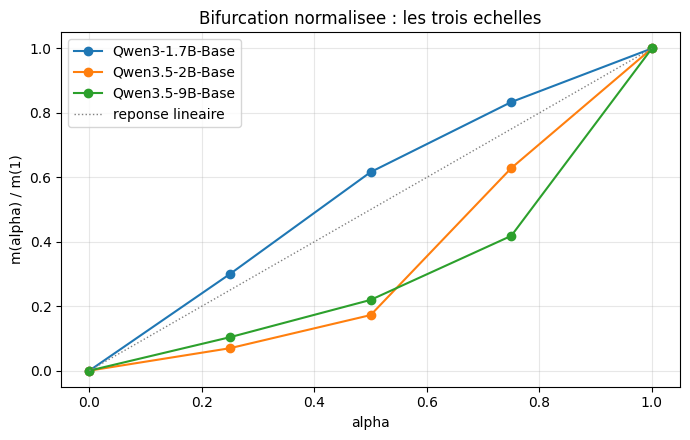

,Qwen3-1.7B-Base,Qwen3.5-2B-Base,Qwen3.5-9B-Base
alpha,,,
0.00,0.0000,0.0000,0.0000
0.25,0.3001,0.0696,0.1037
0.50,0.6163,0.1724,0.2195
0.75,0.8336,0.6286,0.4183
1.00,1.0000,1.0000,1.0000


In [8]:
# Comparaison cross-echelle : courbes normalisees m(alpha)/m(1).

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, t in tables.items():
    agg = t.groupby("alpha")["m"].mean().sort_index()
    ax.plot(agg.index, agg.values / agg.loc[1.0], marker="o", label=label)
ax.plot([0, 1], [0, 1], ":", color="gray", lw=1, label="reponse lineaire")
ax.set_xlabel("alpha")
ax.set_ylabel("m(alpha) / m(1)")
ax.set_title("Bifurcation normalisee : les trois echelles")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cross = pd.DataFrame({
    label: (t.groupby("alpha")["m"].mean() / t.groupby("alpha")["m"].mean().loc[1.0]).round(4)
    for label, t in tables.items()
})
cross


**Comparaison normalisée.** Rapportées à leur divergence finale m(1), les trois courbes s'ordonnent nettement sous la diagonale de réponse linéaire, et d'autant plus bas que l'échelle est grande : le 9B concentre sa réponse sur la toute fin du balayage (m(0.5)/m(1) ≈ 0.22), le 1.7B l'étale dès le début (m(0.25)/m(1) ≈ 0.30, m(0.5)/m(1) ≈ 0.62). Sur trois points, la régularité est frappante — mais trois points dont un changement de dictionnaire ne font pas une loi d'échelle (cf. Limites).


## Contrôle permuté — la spécificité du panel (phase 6)

Le panel différentiel est-il spécial, ou toute collection de 16 features produirait-elle la même divergence ? Contrôle : même taille, tirage uniforme hors panel, seed 42 (`inocrp`), aux intensités du pilote {0.25, 1.0}.


In [9]:
RP_ALPHAS = [0.25, 1.0]


def divergence_table_rp(echelle):
    p0 = inoc_path(echelle, 0.0)
    z0 = np.load(p0, allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    base = {k: sparse_vec(z0, k, d_sae) for k in prompt_keys(z0)}
    rows = []
    for a in RP_ALPHAS:
        z = np.load(ctrl_path("inocrp", echelle, a), allow_pickle=False)
        for key in prompt_keys(z):
            x = sparse_vec(z, key, d_sae)
            rows.append({"alpha": a, "prompt": key,
                         "jeu": key.rsplit("__", 1)[0],
                         "m": float(np.abs(x - base[key]).sum()
                                    / np.abs(base[key]).sum())})
    return pd.DataFrame(rows)


tables_rp = {label: divergence_table_rp(label) for label in ECHELLES}

resume_rp = pd.DataFrame([{
    "echelle": label,
    "panel_m(0.25)": tables[label][tables[label]["alpha"] == 0.25]["m"].mean(),
    "random_m(0.25)": trp[trp["alpha"] == 0.25]["m"].mean(),
    "panel_m(1)": tables[label][tables[label]["alpha"] == 1.0]["m"].mean(),
    "random_m(1)": trp[trp["alpha"] == 1.0]["m"].mean(),
} for label, trp in tables_rp.items()]).round(4)
resume_rp


,echelle,panel_m(0.25),random_m(0.25),panel_m(1),random_m(1)
0,Qwen3-1.7B-Base,0.3311,0.0462,1.1034,0.1808
1,Qwen3.5-2B-Base,0.0450,0.0079,0.6467,0.0102
2,Qwen3.5-9B-Base,0.0339,0.0059,0.3267,0.0062


**Contrôle permuté.** La spécificité du panel tient aux trois échelles, et même se renforce : à α = 1, panel vs tirage aléatoire donnent 1.103 vs 0.181 (×6.1) au 1.7B, 0.647 vs 0.010 (×63) au 2B, **0.327 vs 0.006 (×53)** au 9B. Le 9B n'est donc pas "insensible à toute inoculation" : il est insensible à un panel aléatoire (divergence résiduelle 0.006 ≈ bruit) et spécifiquement sensible au panel différentiel code/prose. La sélectivité ne s'érode pas avec la taille — c'est l'ampleur de la réponse qui diminue.


## Contrôle apparié en norme — le confondant d'activité levé par construction (phase 6b)

Le contrôle permuté hérite d'un confondant : un panel aléatoire tire des features bien moins actives que le panel différentiel, donc un clamp plus faible pour α égal. Contrôle : tirage restreint à la bande d'activité [m/2, 2m] du panel (`inocmp`, seed 42).


In [10]:
MP_ALPHAS = [0.25, 1.0]


def divergence_table_mp(echelle):
    p0 = inoc_path(echelle, 0.0)
    z0 = np.load(p0, allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    base = {k: sparse_vec(z0, k, d_sae) for k in prompt_keys(z0)}
    rows = []
    for a in MP_ALPHAS:
        z = np.load(ctrl_path("inocmp", echelle, a), allow_pickle=False)
        for key in prompt_keys(z):
            x = sparse_vec(z, key, d_sae)
            rows.append({"alpha": a, "prompt": key,
                         "jeu": key.rsplit("__", 1)[0],
                         "m": float(np.abs(x - base[key]).sum()
                                    / np.abs(base[key]).sum())})
    return pd.DataFrame(rows)


tables_mp = {label: divergence_table_mp(label) for label in ECHELLES}

rows_act3 = []
for label, cfg in ECHELLES.items():
    zref = np.load(TRACES / cfg["ref"], allow_pickle=False)
    d_sae = json.loads(str(zref["__meta__"]))["d_sae"]
    act = (mean_by_set(zref, "code_python", d_sae)
           + mean_by_set(zref, "prose_fr", d_sae)) / 2.0
    meta_mp = load_meta(ctrl_path("inocmp", label, 0.25))
    rows_act3.append({
        "echelle": label,
        "act_panel": float(np.mean(act[load_meta(inoc_path(label, 0.0))["clamp_ids"]])),
        "act_apparie": float(np.mean(act[meta_mp["clamp_ids"]])),
        "pool_bande_x8": meta_mp.get("matched_panel_pool"),
    })
audit_act3 = pd.DataFrame(rows_act3)

resume_mp = pd.DataFrame([{
    "echelle": label,
    "panel_m(0.25)": tables[label][tables[label]["alpha"] == 0.25]["m"].mean(),
    "apparie_m(0.25)": tmp[tmp["alpha"] == 0.25]["m"].mean(),
    "panel_m(1)": tables[label][tables[label]["alpha"] == 1.0]["m"].mean(),
    "apparie_m(1)": tmp[tmp["alpha"] == 1.0]["m"].mean(),
} for label, tmp in tables_mp.items()]).round(4)
{"audit_activite": audit_act3.to_dict(), "resume": resume_mp.to_dict()}


{'audit_activite': {'echelle': {0: 'Qwen3-1.7B-Base',
   1: 'Qwen3.5-2B-Base',
   2: 'Qwen3.5-9B-Base'},
  'act_panel': {0: 0.26195846194399547,
   1: 0.0023377667379773353,
   2: 0.012899933080475217},
  'act_apparie': {0: 0.17506777394636014,
   1: 0.0013650935649199005,
   2: 0.002308287502320345},
  'pool_bande_x8': {0: 45, 1: 136, 2: 83}},
 'resume': {'echelle': {0: 'Qwen3-1.7B-Base',
   1: 'Qwen3.5-2B-Base',
   2: 'Qwen3.5-9B-Base'},
  'panel_m(0.25)': {0: 0.3311, 1: 0.045, 2: 0.0339},
  'apparie_m(0.25)': {0: 0.3243, 1: 0.0197, 2: 0.0124},
  'panel_m(1)': {0: 1.1034, 1: 0.6467, 2: 0.3267},
  'apparie_m(1)': {0: 0.8533, 1: 0.08, 2: 0.0446}}}

**Contrôle apparié.** Quand on annule le confondant d'activité (bande ×8, pool 83 candidats pour le 9B, même facteur que le pilote), le tableau se décompose en deux effets. À α = 1 au 9B : panel différentiel 0.327, panel apparié en norme 0.045, panel aléatoire 0.006. Le tirage apparié diverge donc ~7× plus que l'aléatoire — **l'activité de la feature participe de la réponse** — mais reste ~7× sous le panel différentiel — **l'identité différentielle code→prose porte l'essentiel**. Même décomposition qu'au 2B (0.647 / 0.080 / 0.010). Caveat honnête : la bande garantit le même ordre de grandeur, pas la même moyenne (le tirage 9B est tombé à 0.0023 contre 0.0129 pour le panel, bas de bande).


## Fidélité du relevé linéaire J-lens — troisième appareil, même question

L'inoculation mesure ce qu'une **écriture** mi-réseau produit sur la sortie ; le J-lens mesure ce qu'une **lecture** linéaire mi-réseau reconstruit du resid final. Les traces `calib_jlens_*.npz` (pipeline `extract_jlens_fidelity.py`) appliquent à chaque taille un jacobien moyen fit sur WikiText (n = 458) et quantifient l'accord par set de prompts : `overlap@10`, `rel_l2`, KL(modele || lens). Aux deux échelles déjà calibrées s'ajoutent le 9B puis le 27B — chacun via le **lens publié** `neuronpedia/jacobian-lens` (provenance et mesure de l'abandon du fit local 9B : cellule de transparence ci-dessous). Le 27B est la plus grande taille du parc Qwen3.5 couverte par un lens publié.


In [11]:
# Fidelite J-lens aux profondeurs de calibration, quatre echelles.
CALIB = {
    "Qwen3-1.7B-Base": ("traces/calib_jlens_qwen3-1-7b.npz", 7, 14),
    "Qwen3.5-2B-Base": ("traces/calib_jlens_qwen3-5-2b.npz", 6, 12),
    "Qwen3.5-9B-Base": ("traces/calib_jlens_qwen3-5-9b.npz", 8, 16),
    "Qwen3.5-27B": ("traces/calib_jlens_qwen3-5-27b.npz", 16, 32),
}
SETS = ["code_python", "prose_fr", "dialogue", "math", "narrative_en"]
rows = []
for ech, (fname, l_quart, l_midi) in CALIB.items():
    z = np.load(fname, allow_pickle=False)
    if "meta_provenance" in z.files:
        prov = "".join(chr(int(c)) for c in z["meta_provenance"])
        sha16 = "".join(chr(int(c)) for c in z["meta_lens_sha256"])
        if not prov.startswith("local_fit:"):
            print(f"[provenance {ech}] {prov}")
            print(f"[sha256/16]      {sha16} (lens publie, cf. cellule transparence)")
    else:
        print(f"[provenance {ech}] fit local (trace anterieure, cf. cellule transparence)")
    for st in SETS:
        for frac, layer in ((0.25, l_quart), (0.5, l_midi)):
            ov, rl, kl = z[f"{st}__{layer}"]
            rows.append(
                {
                    "echelle": ech,
                    "set": st,
                    "frac": frac,
                    "overlap@10": float(ov),
                    "rel_l2": float(rl),
                    "kl_nats": float(kl),
                }
            )
fidel = pd.DataFrame(rows)
moyennes = fidel.groupby(["frac", "echelle"])[["overlap@10", "rel_l2", "kl_nats"]].mean().round(4)
moyennes


[provenance Qwen3-1.7B-Base] fit local (trace anterieure, cf. cellule transparence)
[provenance Qwen3.5-2B-Base] fit local (trace anterieure, cf. cellule transparence)
[provenance Qwen3.5-9B-Base] neuronpedia/jacobian-lens/qwen3.5-9b-pt/jlens/Salesforce-wikitext/Qwen3.5-9B-Base_jacobian_lens.pt
[sha256/16]      a22ae1995d5adee3 (lens publie, cf. cellule transparence)
[provenance Qwen3.5-27B] neuronpedia/jacobian-lens/qwen3.5-27b/jlens/Salesforce-wikitext/Qwen3.5-27B_jacobian_lens.pt
[sha256/16]      bb2e080ae9c9c208 (lens publie, cf. cellule transparence)


overlap@10  rel_l2  kl_nats
frac echelle                                     
0.25 Qwen3-1.7B-Base      0.0063  0.7644  22.4776
     Qwen3.5-27B          0.0117  1.2676  11.9412
     Qwen3.5-2B-Base      0.0146  1.2356  11.0733
     Qwen3.5-9B-Base      0.0100  0.9713  14.4463
0.50 Qwen3-1.7B-Base      0.0213  0.7711  12.5159
     Qwen3.5-27B          0.0256  0.9613  10.4093
     Qwen3.5-2B-Base      0.0423  1.2251   8.1835
     Qwen3.5-9B-Base      0.0436  0.9579   9.3547

**Le relevé linéaire poursuit sa régression au-delà du 9B.** Moyennes sur les cinq sets à mi-réseau (frac 0.5) : KL 12.52 (1.7B) → 8.18 (2B) → 9.36 (9B) → **10,41 nats (27B)** ; overlap@10 0.021 → 0.042 → 0.044 → 0,026. L'amélioration 1.7B→2B puis la régression 9B s'accentue au 27B : quatre sets sur cinq se dégradent au midi (KL 9B → 27B : code 10.02 → 11.29, prose 10.22 → 10.26, dialogue 9.46 → 11.61, narrative 7.24 → 9.24), seul math tient (9.83 → 9.65).

À toute taille le **gradient de profondeur domine** (KL frac 0.25 > frac 0.5 aux quatre échelles : 22.5 / 11.1 / 14.4 / 11,94 contre 12.5 / 8.2 / 9.4 / 10,41) — mais il **s'atténue au 27B** : à frac 0.25 le 27B repasse devant le 9B (11.94 contre 14.4) et l'écart quart→midi se resserre de 5.0 nats à 1.5. Les profondeurs précoces du grand modèle deviennent plus lisibles pendant que son mi-réseau régresse : l'avantage du linéaire migre des profondeurs tardives vers les précoces relatives.

**Lecture couplée à l'inoculation.** Les deux appareils racontent la même histoire : la part d'une écriture mi-réseau que le resid final propage *linéairement* rétrécit avec la taille — adoucissement de la bifurcation (m(1) 0.647 → 0.327) côté expérience, plateau puis régression du relevé linéaire côté instrument. Le chemin mi-réseau → sortie se médialise de plus en plus par du calcul non linéaire qu'un jacobien moyen statique ne capture pas. Dernier garde-fou : le top-10 du resid final reste hors de portée partout (overlap ≤ 0.07) — le lens répond « dans quelle direction », jamais « quelles features seront actives ».


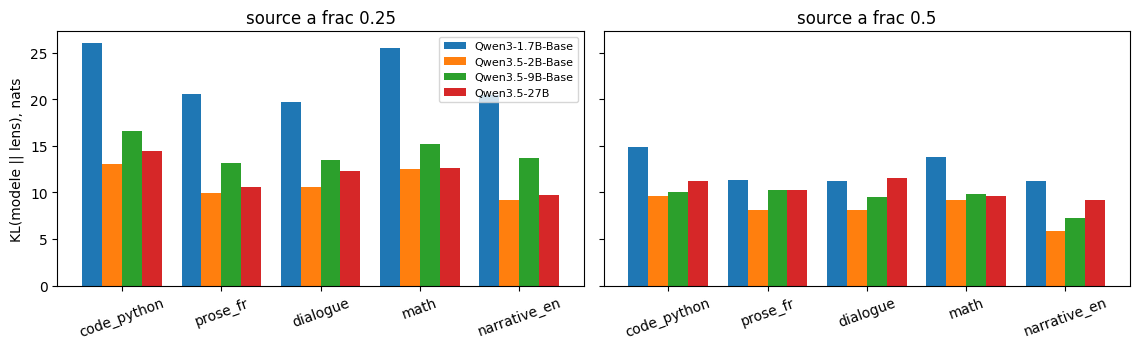

In [12]:
# KL par set et echelle, aux deux profondeurs de calibration.
ordre = ["Qwen3-1.7B-Base", "Qwen3.5-2B-Base", "Qwen3.5-9B-Base", "Qwen3.5-27B"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), sharey=True)
for ax, frac in zip(axes, (0.25, 0.5)):
    piv = (
        fidel[fidel["frac"] == frac]
        .pivot(index="set", columns="echelle", values="kl_nats")
        .loc[SETS, ordre]
    )
    piv.plot.bar(ax=ax, width=0.8, legend=(frac == 0.25))
    ax.set_title(f"source a frac {frac}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
axes[0].set_ylabel("KL(modele || lens), nats")
axes[0].legend(title="", fontsize=8)
plt.tight_layout()
plt.show()


**Transparence de provenance.** 1.7B et 2B : fits locaux (`fit_jlens_local.py`, WikiText n = 458, min 600 car., cible = resid final). 9B : **lens publié** `neuronpedia/jacobian-lens` — spec vérifiée au chargement : 31 couches sources (sur-ensemble des [8, 16] de calibration), cible resid final d_model 4096, n_prompts 458, construction identique. Le fit local 9B a été lancé puis **abandonné sur mesure** : prompt 1 > 69 min sans complétion (GPU sain, 100 % util — chaque passe backward du graphe 32 couches est bornée par la bande passante DRAM), extrapolation ~8-16 jours pour 458 prompts. L'artefact canonique remplace un fit redondant ; `meta_provenance` / `meta_lens_sha256` portent la traçabilité dans la trace. Caveat honnête : un écart d'artefact (fitteur différent) ne s'exclut pas formellement, mais la construction étant identique (mêmes prompts, même cible, même moyenne accumulée), l'écart attendu est de l'ordre de l'accumulation flottante — pas +1.2 nat systématique sur cinq sets.

27B : **lens publié** aussi — `qwen3.5-27b/jlens/Salesforce-wikitext/Qwen3.5-27B_jacobian_lens.pt` (fichier 3 150 Mo, sha256/16 `bb2e080ae9c9c208`, 63 couches sources sur-ensemble des [16, 32] de calibration, d_model 5120, n_prompts 672). **Deux changements de construction assumés à cette taille** : (i) le parc Qwen3.5 n'existe qu'en **instruct** à 27B (pas de jumeau `-Base`, mesuré au Hub et cohérent avec l'inventaire ICT-43) alors que les trois échelles inférieures sont des `-Base` ; (ii) le fit couvre **672** prompts contre 458 au 9B (même dataset, même cible). La fidélité reste une mesure interne (lens comparé à SON modèle), mais la lecture cross-échelle porte ces deux confondants. Côté ressource : le modèle 27B bf16 (~54 Go) ne tient pas en 24 Go de VRAM — l'extraction tourne via l'extension `--offload` de l'organe (init meta + plan accelerate GPU/CPU + lecture tensor par tensor, mesuré : `from_pretrained` matérialise le state dict entier en RAM sur ce transformers Windows), chemin validé au 9B (EXTRACT_OK au 9B, metriques au meme ordre que la trace commitee (KL midi moyen 9.37 vs 9.36, echantillon 1 vs 4 prompts/set)), extraction complète en 8 min sur RTX 3090 + 3080 Ti.


## Limites (assumées, elles délimitent le jalon)

- **Quatre échelles côté J-lens, trois côté inoculation — pas une loi d'échelle.** 1.7B → 2B → 9B → 27B pour la fidélité (les sauts sont hétérogènes, ×1.2 / ×4.5 / ×3, et le 9B change aussi de dictionnaire W64K vs W32K) ; l'inoculation reste mesurée sur trois (pas de traces d'inoculation 27B dans ce carnet). Et le point 27B change DEUX choses à la fois : la taille ET le régime (instruct vs base) ET la taille du fit (672 vs 458 prompts) — un indice sur quatre points dont un double changement de support, jamais un ajustement.
- **Pas d'hystérésis**, passes indépendantes par α (même limite que le pilote).
- **Divergence dans l'espace SAE top-k uniquement** : ce que le dictionnaire ne code pas est invisible.
- **Panel code/prose** : le panel différentiel encode la discrimination code↔prose ; d'autres contrastes (math, dialogue) pourraient inoculer différemment.


## Ce qu'il faut retenir

1. **La bifurcation recule et s'adoucit avec la taille.** À intervention identique (16 features différentielles clampeées à mi-profondeur), le point de transition α* passe de ≈ 0.375 (1.7B) à ≈ 0.625 (2B) à ≈ 0.875 (9B), la pente maximale de 1.40 à 0.76, et la divergence finale m(1) de 1.10 à 0.33. Le 9B est le plus robuste des trois à l'inoculation.
2. **La spécificité, elle, ne s'érode pas.** Contrôle permuté : le 9B répond ×53 plus au panel différentiel qu'à un panel aléatoire (0.327 vs 0.006) — sélectivité préservée, amplitude réduite.
3. **Magnitude et rotation se dissocient.** Le 9B diverge le moins en valeurs (m(1) = 0.33) mais remplace encore 81 % de son top-50 : la bifurcation à grande échelle est une réorganisation plus qu'une destruction.
4. **La fidélité du relevé linéaire ne suit pas l'échelle — et régresse plus fort au 27B.** KL mi-réseau (moyenne 5 sets) : 12.52 → 8.18 → 9.36 → **10.41 nats** — amélioration 1.7B→2B puis régression continue 9B→27B, quatre sets sur cinq d'accord. Au quart de profondeur, mouvement inverse : 11.94 au 27B contre 14.4 au 9B, l'écart quart→midi se resserre de 5.0 à 1.5 nats. Instrument et expérience convergent sur le midi : la part *linéairement* propagée d'une écriture mi-réseau rétrécit avec la taille. Statut : indice sur quatre points dont un double changement de support (27B instruct sans jumeau `-Base`, fit 672 vs 458 prompts), pas une loi d'échelle.


## Exercices


### Exercice 1 — Divergence de Jaccard des top-k par intensité

La statistique m(α) sombre toutes les features. Exercice : pour le 9B, calculez l'indice de Jaccard `|top50_a ∩ top50_0| / |top50_a ∪ top50_0|` par prompt aux cinq intensités, moyennez, et comparez sa courbe J(α) à m(α) : la bifurcation est-elle un phénomène de *rotation* (mêmes features, valeurs déplacées) ou de *remplacement* (features différentes) ?


In [13]:
# Exercice 1 : divergence de Jaccard des top-k par intensite (9B).

ech = "Qwen3.5-9B-Base"
z0 = np.load(inoc_path(ech, 0.0), allow_pickle=False)
rows = []
for a in ALPHAS:
    z = np.load(inoc_path(ech, a), allow_pickle=False)
    jac = []
    for key in prompt_keys(z):
        ids0 = set(z0[f"{key}__topk_ids"].astype(np.int64).ravel().tolist())
        idsa = set(z[f"{key}__topk_ids"].astype(np.int64).ravel().tolist())
        jac.append(len(ids0 & idsa) / len(ids0 | idsa))
    rows.append({"alpha": a, "jaccard_moyen": float(np.mean(jac))})
pd.DataFrame(rows)


,alpha,jaccard_moyen
0,0.00,1.000000
1,0.25,0.954942
2,0.50,0.915326
3,0.75,0.854536
4,1.00,0.735630


### Exercice 2 — La rupture dépend-elle du jeu ?

Les deux jeux qui définissent le panel (code_python, prose_fr) sont-ils aussi ceux qui divergent le plus ? Exercice : pour chaque échelle, calculez m(0.5) par jeu et classez ; testez si les jeux du panel dominent la divergence aux trois échelles.


In [14]:
# Exercice 2 : m(alpha) par jeu, jeux du panel vs jeux neutres.

rows = []
for label, t in tables.items():
    g = t[t["alpha"] == 0.5].groupby("jeu")["m"].mean().sort_values(ascending=False)
    for jeu, m in g.items():
        rows.append({"echelle": label, "jeu": jeu, "m(0.5)": round(float(m), 4),
                     "jeu_du_panel": jeu in ("code_python", "prose_fr")})
pd.DataFrame(rows).pivot_table(index="echelle", columns="jeu", values="m(0.5)")


jeu,code_python,dialogue,math,narrative_en,prose_fr
echelle,,,,,
Qwen3-1.7B-Base,0.7442,0.6234,0.7057,0.7207,0.6059
Qwen3.5-2B-Base,0.0549,0.1448,0.1034,0.1132,0.1411
Qwen3.5-9B-Base,0.0562,0.0882,0.0737,0.0525,0.0879


### Exercice 3 — Les échelles traversent-elles la transition dans le même ordre ?

Par prompt : le rang de divergence au α=0.5 est-il concordant entre échelles ? Exercice : appariez les prompts par clé (les jeux sont identiques), calculez un Spearman par paire d'échelles sur m(0.5) par prompt, et concluez sur l'existence d'un profil de prompt « sensible » commun.


In [15]:
# Exercice 3 : Spearman par paire d'echelles sur m(0.5) par prompt.

from scipy.stats import spearmanr

m05 = {label: t[t["alpha"] == 0.5].set_index("prompt")["m"]
       for label, t in tables.items()}
labels = list(ECHELLES)
rows = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        a, b = m05[labels[i]], m05[labels[j]]
        common = a.index.intersection(b.index)
        rho, p = spearmanr(a.loc[common], b.loc[common])
        rows.append({"paire": f"{labels[i]} vs {labels[j]}",
                     "n_prompts_communs": len(common),
                     "spearman_rho": round(float(rho), 4), "p_value": float(p)})
pd.DataFrame(rows)


,paire,n_prompts_communs,spearman_rho,p_value
0,Qwen3-1.7B-Base vs Qwen3.5-2B-Base,20,-0.7053,0.000514
1,Qwen3-1.7B-Base vs Qwen3.5-9B-Base,20,-0.6331,0.002734
2,Qwen3.5-2B-Base vs Qwen3.5-9B-Base,20,0.5113,0.021221
